# Problem Statement: To analyze the factors that influence sleep quality in adults.

In [41]:
# importing libraries that we will use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importing the dataset
df = pd.read_csv("sleep.csv")

## 1. Dataset Overview

In [94]:
print('shape: ' + str(df.shape)) # 100 rows and 12 columns
df.info()

shape: (100, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      100 non-null    int64  
 1   Gender                   100 non-null    object 
 2   Sleep Quality            100 non-null    int64  
 3   Bedtime                  100 non-null    float64
 4   Wake-up Time             100 non-null    float64
 5   Daily Steps              100 non-null    int64  
 6   Calories Burned          100 non-null    int64  
 7   Physical Activity Level  100 non-null    int64  
 8   Dietary Habits           100 non-null    int64  
 9   Sleep Disorders          100 non-null    object 
 10  Medication Usage         100 non-null    object 
 11  Sleep Time               100 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 9.5+ KB


In [15]:
df.describe()

,User ID,Age,Sleep Quality,Daily Steps,Calories Burned
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,36.010000,7.000000,6830.000000,2421.00000
std,29.011492,8.454865,1.734964,2498.706736,281.06759
min,1.000000,22.000000,4.000000,3000.000000,2000.00000
25%,25.750000,28.750000,5.750000,4750.000000,2175.00000
50%,50.500000,35.000000,7.500000,6750.000000,2400.00000
75%,75.250000,44.000000,8.250000,9000.000000,2700.00000
max,100.000000,50.000000,9.000000,11000.000000,2900.00000


In [16]:
df.head()

,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no


In [ ]:
# We are provided with 11 factors that may impact sleep quality.
# In this project, we will analyze each factor to understand its impact on sleep patterns in adults using visualizations and drawing conclusions.


## 2. Data Cleaning

In [42]:
# Here User ID is not relevant as we already have indices for them. We can drop the column.
df = df.drop('User ID', axis=1)

In [29]:
# Checking for any missing data:
df.isna().sum()

# we can conclude that there are no missing data

Age                        0
Gender                     0
Sleep Quality              0
Bedtime                    0
Wake-up Time               0
Daily Steps                0
Calories Burned            0
Physical Activity Level    0
Dietary Habits             0
Sleep Disorders            0
Medication Usage           0
dtype: int64

In [43]:
# The physical activity level is given in low, medium and high. We can map this to integral values such as 1, 2, and 3 so we can sort them easier. 
# We can do this by mapping.

PALnotation = {'low': 1, 'medium': 2, 'high': 3}
df['Physical Activity Level'] = df['Physical Activity Level'].map(PALnotation)

In [44]:
# We can do the same with dietary habits. 

DHnotation = {'unhealthy': 1, 'medium': 2, 'healthy': 3}
df['Dietary Habits'] = df['Dietary Habits'].map(DHnotation)

In [ ]:
# Since the time is in strings, we have to convert it into integers so we can calculate the sleep duration. 

def timeConverter(t):
    hour,minute = t.split(':')
    return int(hour)+int(minute)/60

df['Bedtime'] =  df['Bedtime'].apply(timeConverter)
df['Wake-up Time'] = df['Wake-up Time'].apply(timeConverter)

df['Sleep Time'] = (df['Wake-up Time']-df['Bedtime'])%24 # sleep duration is in hours

## 3. Data Analysis and Visualisation

#### a. Sleep Quality vs Age

In [49]:
AgeSleepQualityCorr = df['Age'].corr(df['Sleep Quality'])
AgeSleepQualityCorr
# we can see that there is a high negative correlation between age and sleep quality

np.float64(-0.848356291226265)

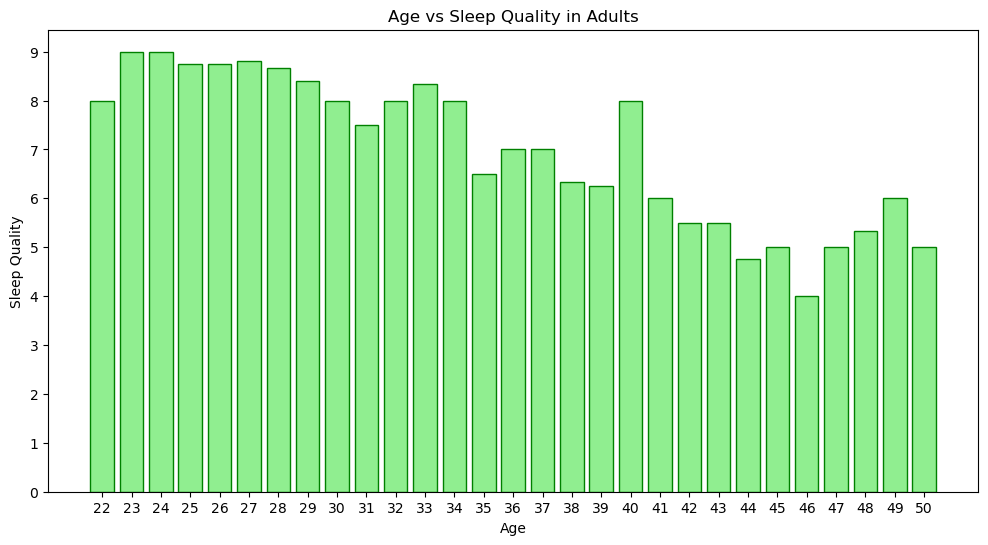

In [50]:
MeanSleepQualityPerAge = df.groupby('Age')['Sleep Quality'].mean()

labels = MeanSleepQualityPerAge.index
values = MeanSleepQualityPerAge.values

plt.figure(figsize = (12,6))
plt.bar(labels,values,color='lightgreen', edgecolor='green')
plt.xticks(MeanSleepQualityPerAge.index)
plt.yticks(np.arange(0,df['Sleep Quality'].max()+1))
plt.xlabel('Age')
plt.ylabel('Sleep Quality')
plt.title('Age vs Sleep Quality in Adults')

plt.show()

# Sleep Quality decreases with age.

#### b. Sleep Quality vs Physical Activity

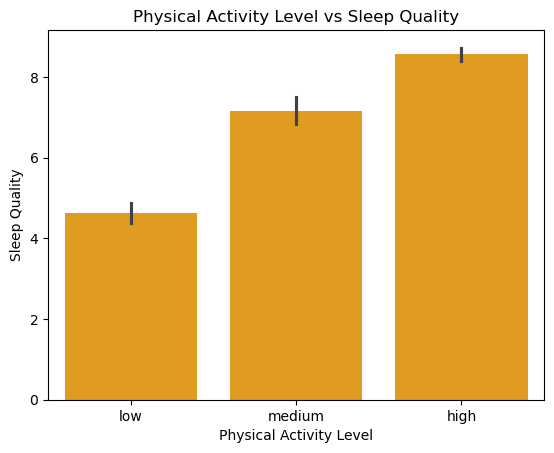

In [58]:
sns.barplot(x='Physical Activity Level', y='Sleep Quality', data=df, order=[1,2,3],color='orange')

plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Quality')
plt.xticks([0,1,2], ['low', 'medium', 'high']) 
plt.title('Physical Activity Level vs Sleep Quality')
plt.show()

# Sleep Quality increases with physical activity level.

#### c. Sleep Quality vs Sleep Duration

In [69]:
# first let's see a relation between physical activity and sleep duration 

SleepTimePhysicalActivityCorr = df['Sleep Time'].corr(df['Physical Activity Level'])
print(SleepTimePhysicalActivityCorr)

# there is a very high positive correlation

0.8049495235911522


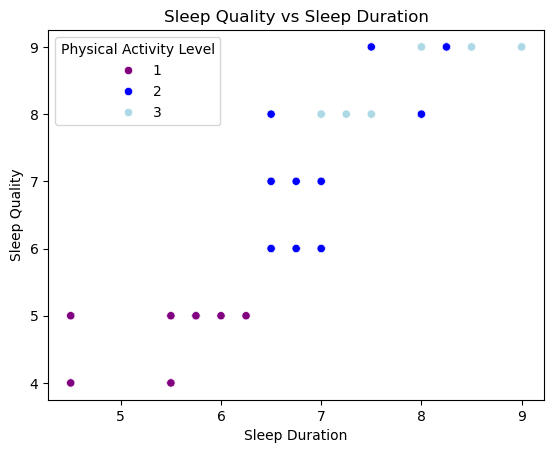

In [78]:
sns.scatterplot(x='Sleep Time', y='Sleep Quality',hue='Physical Activity Level', palette=['purple','blue','lightblue'],data=df)
# We can use hue to visualise physical activity level with sleep duration as well since we know that from the correlation.

plt.xlabel('Sleep Duration')
plt.ylabel('Sleep Quality')
plt.title('Sleep Quality vs Sleep Duration')
plt.show()

#### d. Sleep Quality vs Dietary Habits

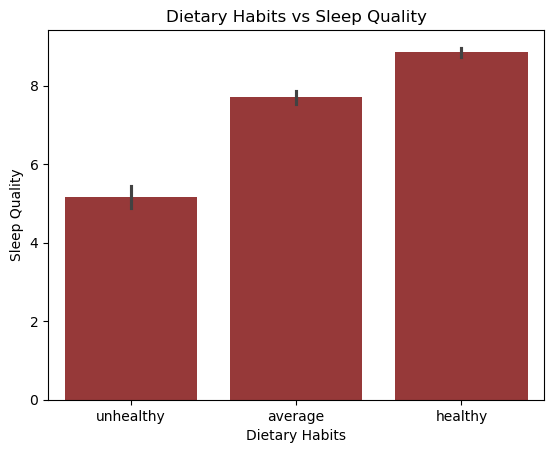

In [76]:
sns.barplot(x='Dietary Habits', y='Sleep Quality', data=df, order=[1,2,3],color='brown')

plt.xlabel('Dietary Habits')
plt.ylabel('Sleep Quality')
plt.xticks([0,1,2], ['unhealthy', 'average', 'healthy']) 
plt.title('Dietary Habits vs Sleep Quality')
plt.show()

### e. Gender vs Sleep Quality

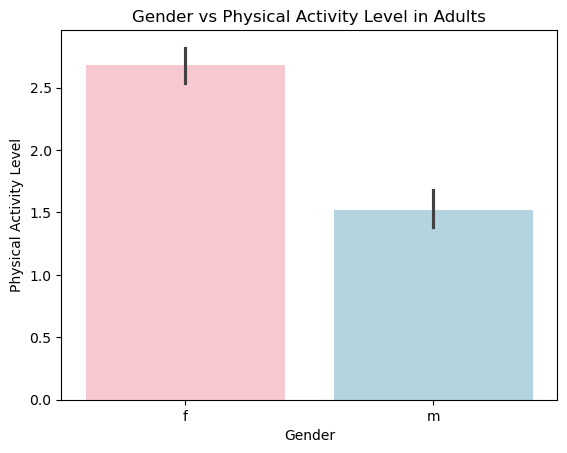

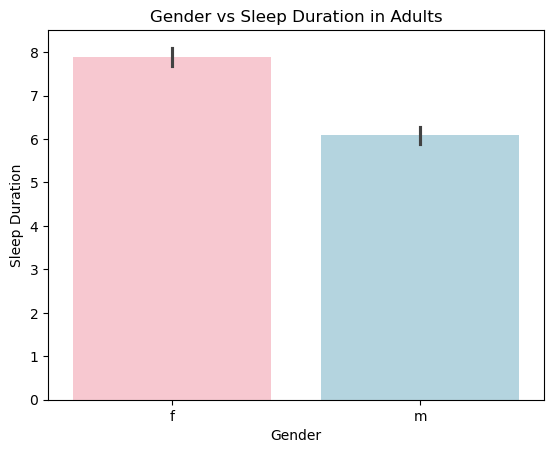

In [95]:
# Before we can check the relations between gender and sleep quality, lets see which gender has better physical activities and sleep duration.

PALvsG = sns.barplot(x='Gender', y='Physical Activity Level', data=df, palette=['pink','lightblue'],hue='Gender')

plt.xlabel('Gender')
plt.ylabel('Physical Activity Level')
plt.title('Gender vs Physical Activity Level in Adults')
plt.show()

STvsG = sns.barplot(x='Gender', y='Sleep Time', data=df, palette=['pink','lightblue'],hue='Gender')

plt.xlabel('Gender')
plt.ylabel('Sleep Duration')
plt.title('Gender vs Sleep Duration in Adults')
plt.show()

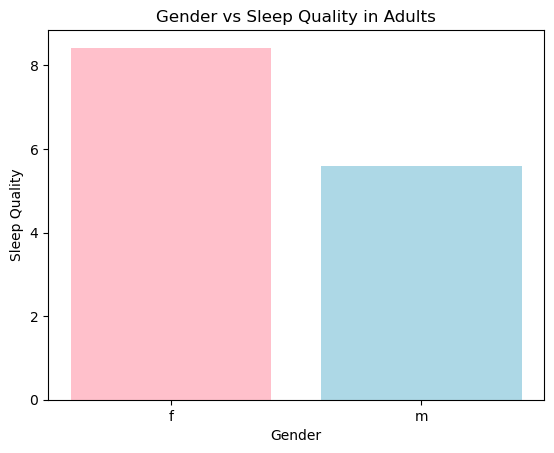

In [86]:
# now we can see the relation b/w sleep quality and gender

MeanSleapQualityPerGender = df.groupby('Gender')['Sleep Quality'].mean()
labels = MeanSleapQualityPerGender.index
values = MeanSleapQualityPerGender.values

plt.bar(labels,values,color=['pink','lightblue'])
plt.xlabel('Gender')
plt.ylabel('Sleep Quality')
plt.xticks()
plt.yticks(np.arange(0,10,2))
plt.title('Gender vs Sleep Quality in Adults')
plt.show()

# Since females have better physical activity levels and higher sleep duration we can conclude that they have better sleep quality. 
# Hence gender cannot be a determining factor in sleep quality.

### f. Physical Activity Level vs Calories Burned vs Daily Steps

In [93]:
PAL_CB_DS_corr = df[['Physical Activity Level','Calories Burned', 'Daily Steps']].corr()
PAL_CB_DS_corr

# here we can see that PAL, CB and DS are all highly correlated with one and another, hence sleep quality increases with calories burned and daily steps

,Physical Activity Level,Calories Burned,Daily Steps
Physical Activity Level,1.000000,0.869424,0.884245
Calories Burned,0.869424,1.000000,0.986750
Daily Steps,0.884245,0.986750,1.000000


## 4. Conclusion

### Correlation Heatmap

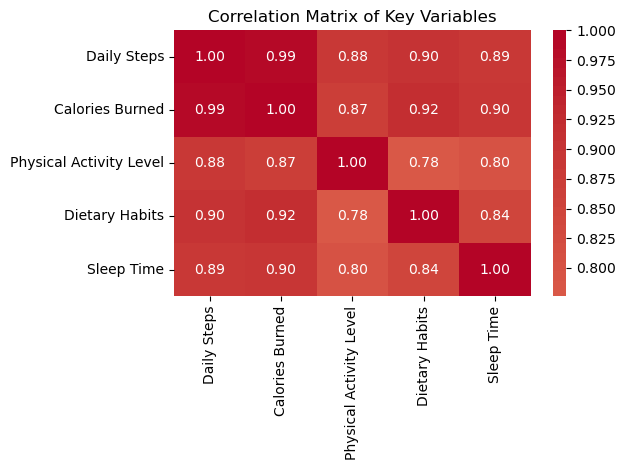

In [100]:
corr = df[['Daily Steps', 'Calories Burned', 'Physical Activity Level',
       'Dietary Habits', 'Sleep Time']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',center=0)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Finally we can conlcude from the analysis:

# Sleep Quality decreases with Age in a linear manner.
# Sleep Quality increases with Physical Activity Level and Sleep Duration.
# Sleep Quality increases with better Dietary Habits and with higher Calories Burned and Daily Steps.
# Overall, being healthy leads to better Sleep Quality.